## Load the Dataset

In [1]:
import pandas as pd
import numpy as np

# Load the survey responses from CSV
file_path = r"C:\Work area\Data_science\New folder\DS_SemVI_CP_DataSet.csv"
df = pd.read_csv(file_path)

# Preview raw data
print("Original Data:")
df.head()


Original Data:


,Timestamp,Name (initials only),Where do you usually sit during lectures? (specify one seat number),Do you prefer sitting closer to the .....,"Why do you choose this seating position?\n(Comfort, habit, group preference, proximity to teacher, distractions, etc.)",Do you sit in the same position across different subjects or classes?,Are you more attentive when seated at the...,What is your current CGP ?,Do you believe your usual seating position has affected your academic performance?,Have you ever changed your seating position and noticed a difference in your learning or grades?,"Follow up question, if changing your seating position has led to positive impact where was it ?",Are you comfortable participating in class from your usual seat?,How often do you interact with the teacher during class?,How focused do you feel during lectures based on where you're seated?,What is your attendance percentage ?,"If assigned a different seat next class, would it affect your focus or engagement?",How many times during lectures last week did you speak or ask a question to your teacher (either voluntarily or when called upon)?
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,03/06/2025 18:52:52,Tarunika T,27,Window,Comfort and habit,Yes,Front,7.0 – 7.9,No noticeable effect,Yes – it improved,Front row,Maybe,2.0,3.0,80-100%,No,1–2 times – Just once or twice
2,03/06/2025 18:57:59,SJ,"4,13,7,16",Peers,Closer to friends and teacher,Yes,Front,8.0 – 8.9,"Yes, positively",No difference,Front row,Yes,4.0,4.0,60-80%,Yes,3–5 times – Occasionally participated
3,03/06/2025 19:01:24,N,11,Window,Group preference,No,Front,6.0 – 6.9,No noticeable effect,Yes – it improved,Left alone,Maybe,2.0,2.0,80-100%,Yes,3–5 times – Occasionally participated
4,03/06/2025 19:10:21,R,17,Window,Habit,Yes,Front,8.0 – 8.9,No noticeable effect,No difference,Front row,Yes,2.0,3.0,80-100%,No,1–2 times – Just once or twice


## Rename Columns for Simplicity

In [2]:
# Simplify column names for easier analysis
rename_dict = {
    'Timestamp': 'Timestamp',
    'Name (initials only)': 'Name',
    'Where do you usually sit during lectures? (specify one seat number)': 'Seat_number',
    'Do you prefer sitting closer to the .....': 'Seat_preference',
    'Why do you choose this seating position?\n(Comfort, habit, group preference, proximity to teacher, distractions, etc.)  ': 'Reason',
    'Do you sit in the same position across different subjects or classes? ': 'Same_position',
    'Are you more attentive when seated at the...': 'Attentive_zone',
    'What is your current CGP ?': 'Cgp',
    'Do you believe your usual seating position has affected your academic performance?  ': 'seat_affect_performance',
    'Have you ever changed your seating position and noticed a difference in your learning or grades? ': 'seat_change_effect',
    'Follow up question, if changing your seating position has led to positive impact where was it ?': 'seat_change_location',
    'Are you comfortable participating in class from your usual seat?': 'comfortable_participation',
    'How often do you interact with the teacher during class? ': 'teacher_interaction',
    "How focused do you feel during lectures based on where you're seated? ": 'focus_rating',
    'What is your attendance percentage ?': 'attendance',
    'If assigned a different seat next class, would it affect your focus or engagement?  ': 'seat_change_effect_on_focus',
    'How many times during lectures last week did you speak or ask a question to your teacher (either voluntarily or when called upon)?  ': 'questions_asked'
}
df.rename(columns=rename_dict, inplace=True)

# Check column name changes
print("After Renaming Columns:")
df.head()


After Renaming Columns:


,Timestamp,Name,Seat_number,Seat_preference,Reason,Same_position,Attentive_zone,Cgp,seat_affect_performance,seat_change_effect,seat_change_location,comfortable_participation,teacher_interaction,focus_rating,attendance,seat_change_effect_on_focus,questions_asked
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,03/06/2025 18:52:52,Tarunika T,27,Window,Comfort and habit,Yes,Front,7.0 – 7.9,No noticeable effect,Yes – it improved,Front row,Maybe,2.0,3.0,80-100%,No,1–2 times – Just once or twice
2,03/06/2025 18:57:59,SJ,"4,13,7,16",Peers,Closer to friends and teacher,Yes,Front,8.0 – 8.9,"Yes, positively",No difference,Front row,Yes,4.0,4.0,60-80%,Yes,3–5 times – Occasionally participated
3,03/06/2025 19:01:24,N,11,Window,Group preference,No,Front,6.0 – 6.9,No noticeable effect,Yes – it improved,Left alone,Maybe,2.0,2.0,80-100%,Yes,3–5 times – Occasionally participated
4,03/06/2025 19:10:21,R,17,Window,Habit,Yes,Front,8.0 – 8.9,No noticeable effect,No difference,Front row,Yes,2.0,3.0,80-100%,No,1–2 times – Just once or twice


## Drop Irrelevant Columns and Cleanup First Row

In [3]:
# Drop 'Timestamp' as it's not needed for analysis
new_df = df.drop(columns=['Timestamp'])

# Drop the first row if it's almost entirely empty (form artifact)
if new_df.iloc[0].isna().sum() >= len(new_df.columns) - 1:
    new_df = new_df.drop(index=0).reset_index(drop=True)

# Check result of cleanup
print("After Dropping Timestamp and Empty First Row:")
new_df.head()


After Dropping Timestamp and Empty First Row:


,Name,Seat_number,Seat_preference,Reason,Same_position,Attentive_zone,Cgp,seat_affect_performance,seat_change_effect,seat_change_location,comfortable_participation,teacher_interaction,focus_rating,attendance,seat_change_effect_on_focus,questions_asked
0,Tarunika T,27,Window,Comfort and habit,Yes,Front,7.0 – 7.9,No noticeable effect,Yes – it improved,Front row,Maybe,2.0,3.0,80-100%,No,1–2 times – Just once or twice
1,SJ,"4,13,7,16",Peers,Closer to friends and teacher,Yes,Front,8.0 – 8.9,"Yes, positively",No difference,Front row,Yes,4.0,4.0,60-80%,Yes,3–5 times – Occasionally participated
2,N,11,Window,Group preference,No,Front,6.0 – 6.9,No noticeable effect,Yes – it improved,Left alone,Maybe,2.0,2.0,80-100%,Yes,3–5 times – Occasionally participated
3,R,17,Window,Habit,Yes,Front,8.0 – 8.9,No noticeable effect,No difference,Front row,Yes,2.0,3.0,80-100%,No,1–2 times – Just once or twice
4,R,17,Window,Comfort,Yes,Front,8.0 – 8.9,No noticeable effect,No difference,Middle rows,Maybe,2.0,3.0,80-100%,No,0 times – I did not speak or ask any questions


## Clean and Encode 'Same_position'

In [4]:
# Convert to title case and map Yes/No to binary
new_df['Same_position'] = new_df['Same_position'].str.strip().str.title()
new_df['Same_position'] = new_df['Same_position'].map({'Yes': 1, 'No': 0})

# View changes
print("After Encoding 'Same_position':")
new_df[['Same_position']].head()


After Encoding 'Same_position':


,Same_position
0,1
1,1
2,0
3,1
4,1


## One-Hot Encode

In [5]:
# One-hot encode attentive zones
new_df = pd.get_dummies(new_df, columns=['Attentive_zone'], prefix='Zone')

# Confirm encoding
print("After One-hot Encoding 'Attentive_zone':")
new_df.head()


After One-hot Encoding 'Attentive_zone':


,Name,Seat_number,Seat_preference,Reason,Same_position,Cgp,seat_affect_performance,seat_change_effect,seat_change_location,comfortable_participation,teacher_interaction,focus_rating,attendance,seat_change_effect_on_focus,questions_asked,Zone_Back,Zone_Front,Zone_Middle,Zone_Sides
0,Tarunika T,27,Window,Comfort and habit,1,7.0 – 7.9,No noticeable effect,Yes – it improved,Front row,Maybe,2.0,3.0,80-100%,No,1–2 times – Just once or twice,False,True,False,False
1,SJ,"4,13,7,16",Peers,Closer to friends and teacher,1,8.0 – 8.9,"Yes, positively",No difference,Front row,Yes,4.0,4.0,60-80%,Yes,3–5 times – Occasionally participated,False,True,False,False
2,N,11,Window,Group preference,0,6.0 – 6.9,No noticeable effect,Yes – it improved,Left alone,Maybe,2.0,2.0,80-100%,Yes,3–5 times – Occasionally participated,False,True,False,False
3,R,17,Window,Habit,1,8.0 – 8.9,No noticeable effect,No difference,Front row,Yes,2.0,3.0,80-100%,No,1–2 times – Just once or twice,False,True,False,False
4,R,17,Window,Comfort,1,8.0 – 8.9,No noticeable effect,No difference,Middle rows,Maybe,2.0,3.0,80-100%,No,0 times – I did not speak or ask any questions,False,True,False,False


In [6]:
print(new_df.columns)

Index(['Name', 'Seat_number', 'Seat_preference', 'Reason', 'Same_position',
       'Cgp', 'seat_affect_performance', 'seat_change_effect',
       'seat_change_location', 'comfortable_participation',
       'teacher_interaction', 'focus_rating', 'attendance',
       'seat_change_effect_on_focus', 'questions_asked', 'Zone_Back',
       'Zone_Front', 'Zone_Middle', 'Zone_Sides'],
      dtype='object')


In [7]:
# One-hot encode seat preference
new_df = pd.get_dummies(new_df, columns=['Seat_preference'], prefix='Pref')

# Confirm encoding
print("After One-hot Encoding 'Seat_preference':")
new_df.head()


After One-hot Encoding 'Seat_preference':


,Name,Seat_number,Reason,Same_position,Cgp,seat_affect_performance,seat_change_effect,seat_change_location,comfortable_participation,teacher_interaction,...,questions_asked,Zone_Back,Zone_Front,Zone_Middle,Zone_Sides,Pref_Black Board,Pref_Fan,Pref_Peers,Pref_Teacher,Pref_Window
0,Tarunika T,27,Comfort and habit,1,7.0 – 7.9,No noticeable effect,Yes – it improved,Front row,Maybe,2.0,...,1–2 times – Just once or twice,False,True,False,False,False,False,False,False,True
1,SJ,"4,13,7,16",Closer to friends and teacher,1,8.0 – 8.9,"Yes, positively",No difference,Front row,Yes,4.0,...,3–5 times – Occasionally participated,False,True,False,False,False,False,True,False,False
2,N,11,Group preference,0,6.0 – 6.9,No noticeable effect,Yes – it improved,Left alone,Maybe,2.0,...,3–5 times – Occasionally participated,False,True,False,False,False,False,False,False,True
3,R,17,Habit,1,8.0 – 8.9,No noticeable effect,No difference,Front row,Yes,2.0,...,1–2 times – Just once or twice,False,True,False,False,False,False,False,False,True
4,R,17,Comfort,1,8.0 – 8.9,No noticeable effect,No difference,Middle rows,Maybe,2.0,...,0 times – I did not speak or ask any questions,False,True,False,False,False,False,False,False,True


## Convert CGP Ranges to Midpoints

In [8]:
print("Original CGP column:")
print(new_df['Cgp'].head(10))
print("With repr (to see hidden characters):")
for val in new_df['Cgp'].head(10):
    print(repr(val))


Original CGP column:
0     7.0 – 7.9
1     8.0 – 8.9
2     6.0 – 6.9
3     8.0 – 8.9
4     8.0 – 8.9
5    9.0 – 10.0
6     8.0 – 8.9
7    9.0 – 10.0
8    9.0 – 10.0
9     8.0 – 8.9
Name: Cgp, dtype: object
With repr (to see hidden characters):
'7.0 – 7.9'
'8.0 – 8.9'
'6.0 – 6.9'
'8.0 – 8.9'
'8.0 – 8.9'
'9.0 – 10.0'
'8.0 – 8.9'
'9.0 – 10.0'
'9.0 – 10.0'
'8.0 – 8.9'


In [9]:
import re

def convert_cgp(val):
    try:
        if pd.isna(val):
            return None
        val = str(val).strip()

        # Normalize dashes and spacing
        val = val.replace('–', '-').replace('−', '-')  # en dash, minus
        val = re.sub(r'\s*-\s*', '-', val)  # remove spaces around dash

        parts = val.split('-')
        if len(parts) != 2:
            print(f"Invalid CGP format: '{val}'")
            return None
        return (float(parts[0]) + float(parts[1])) / 2
    except Exception as e:
        print(f"Error converting '{val}': {e}")
        return None


In [10]:
new_df['Cgp'] = new_df['Cgp'].apply(convert_cgp)

In [11]:
print(new_df['Cgp'].head(10))
print("Null CGP count:", new_df['Cgp'].isna().sum())


0    7.45
1    8.45
2    6.45
3    8.45
4    8.45
5    9.50
6    8.45
7    9.50
8    9.50
9    8.45
Name: Cgp, dtype: float64
Null CGP count: 0


In [12]:
print(new_df['Cgp'].head(10))
print("Null CGP count:", new_df['Cgp'].isna().sum())


0    7.45
1    8.45
2    6.45
3    8.45
4    8.45
5    9.50
6    8.45
7    9.50
8    9.50
9    8.45
Name: Cgp, dtype: float64
Null CGP count: 0


In [13]:
print(new_df[[ 'Cgp', 'Zone_Front', 'Zone_Front']].head(10))
print("Check product (Zone_Front * Cgp):")
print((new_df['Zone_Front'] * new_df['Cgp']).head(10))


    Cgp  Zone_Front  Zone_Front
0  7.45        True        True
1  8.45        True        True
2  6.45        True        True
3  8.45        True        True
4  8.45        True        True
5  9.50       False       False
6  8.45       False       False
7  9.50       False       False
8  9.50       False       False
9  8.45        True        True
Check product (Zone_Front * Cgp):
0    7.45
1    8.45
2    6.45
3    8.45
4    8.45
5    0.00
6    0.00
7    0.00
8    0.00
9    8.45
dtype: float64


## Encode 'seat_affect_performance'

In [14]:
# Map 'Yes' to 1, others to 0
new_df['seat_affect_performance'] = new_df['seat_affect_performance'].apply(
    lambda x: 1 if isinstance(x, str) and 'Yes' in x else 0
)

# Check conversion
print("After Encoding 'seat_affect_performance':")
new_df[['seat_affect_performance']].head()


After Encoding 'seat_affect_performance':


,seat_affect_performance
0,0
1,1
2,0
3,0
4,0


## Convert 'teacher_interaction' to Numeric

In [15]:
# Convert to float, coercing non-numeric to NaN
new_df['teacher_interaction'] = pd.to_numeric(new_df['teacher_interaction'], errors='coerce')

# Check result
print("After Converting 'teacher_interaction' to Numeric:")
new_df[['teacher_interaction']].head()


After Converting 'teacher_interaction' to Numeric:


,teacher_interaction
0,2.0
1,4.0
2,2.0
3,2.0
4,2.0


 ## Final Missing Value & Stats Check

In [16]:
# Missing values per column
print("Missing Values Per Column:")
print(new_df.isna().sum())

# Descriptive statistics of final dataset
print("\nFinal Dataset Summary:")
new_df.describe(include='all')


Missing Values Per Column:
Name                           0
Seat_number                    0
Reason                         0
Same_position                  0
Cgp                            0
seat_affect_performance        0
seat_change_effect             0
seat_change_location           3
comfortable_participation      0
teacher_interaction            0
focus_rating                   0
attendance                     0
seat_change_effect_on_focus    0
questions_asked                0
Zone_Back                      0
Zone_Front                     0
Zone_Middle                    0
Zone_Sides                     0
Pref_Black Board               0
Pref_Fan                       0
Pref_Peers                     0
Pref_Teacher                   0
Pref_Window                    0
dtype: int64

Final Dataset Summary:


,Name,Seat_number,Reason,Same_position,Cgp,seat_affect_performance,seat_change_effect,seat_change_location,comfortable_participation,teacher_interaction,...,questions_asked,Zone_Back,Zone_Front,Zone_Middle,Zone_Sides,Pref_Black Board,Pref_Fan,Pref_Peers,Pref_Teacher,Pref_Window
count,67,67,67,67.000000,67.000000,67.000000,67,64,67,67.000000,...,67,67,67,67,67,67,67,67,67,67
unique,62,32,36,NaN,NaN,NaN,3,6,3,NaN,...,5,2,2,2,2,2,2,2,2,2
top,N,27,Comfort,NaN,NaN,NaN,No difference,Middle rows,Yes,NaN,...,1–2 times – Just once or twice,False,False,False,False,False,False,False,False,True
freq,3,6,17,NaN,NaN,NaN,46,16,45,NaN,...,25,54,41,47,59,65,54,56,65,39
mean,NaN,NaN,NaN,0.805970,7.947761,0.447761,NaN,NaN,NaN,2.865672,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,0.398437,1.038043,0.501017,NaN,NaN,NaN,1.099525,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,0.000000,2.500000,0.000000,NaN,NaN,NaN,1.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,1.000000,7.450000,0.000000,NaN,NaN,NaN,2.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,1.000000,8.450000,0.000000,NaN,NaN,NaN,3.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,1.000000,8.450000,1.000000,NaN,NaN,NaN,4.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### the 3 missing values in seat_change_location are from a question in the survey that was given as optional. 

## Exploaratory Data Analytics

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

### 1. Bar Plot = Seating Preferences Count 

In [18]:
zone_cols = ['Zone_Front', 'Zone_Back', 'Zone_Middle', 'Zone_Sides']

def get_seat_pref(row):
    for col in zone_cols:
        if row[col] == 1:
            return col.replace('Zone_', '')
    return 'Unknown'

new_df['Seat_preference'] = new_df.apply(get_seat_pref, axis=1)

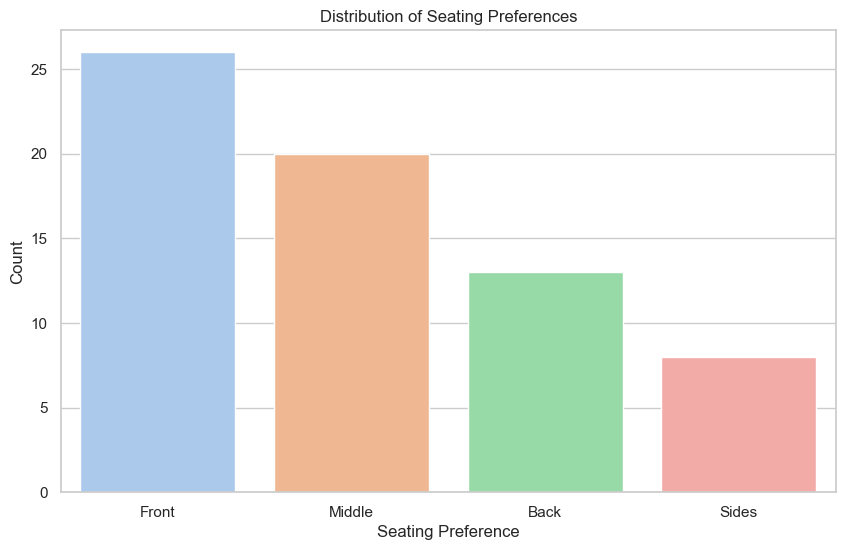

In [19]:
sns.countplot(data=new_df, x='Seat_preference', palette='pastel')
plt.title('Distribution of Seating Preferences')
plt.xlabel('Seating Preference')
plt.ylabel('Count')
plt.show()

### 2. Heatmap: Correlation matrix

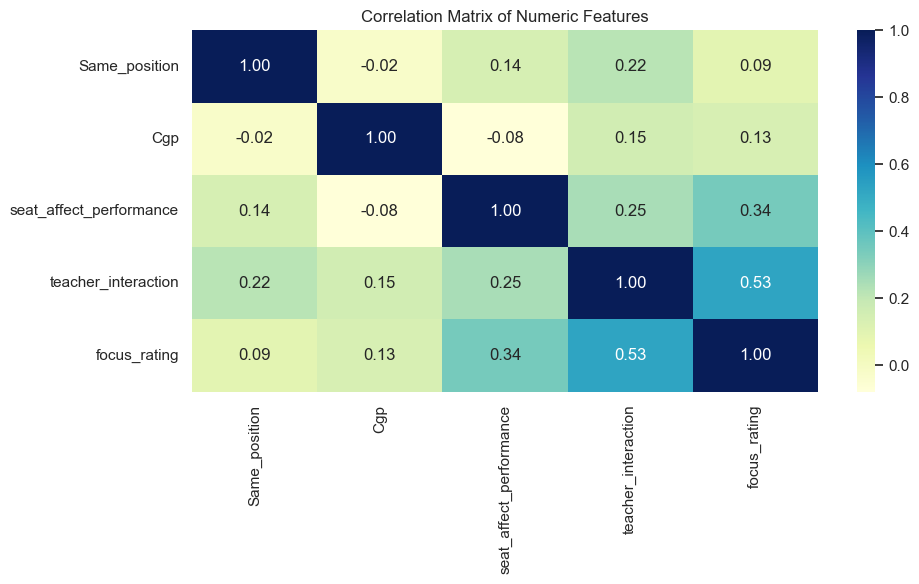

In [20]:
numeric_cols = new_df.select_dtypes(include=['float64', 'int64'])
corr = numeric_cols.corr()

sns.heatmap(corr, annot=True, cmap='YlGnBu', fmt=".2f")
plt.title('Correlation Matrix of Numeric Features')
plt.tight_layout()
plt.show()

### 3. Stripplot to depict the co-relation between the student-teacher interaction and the CGPA

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_4920\2016714726.py:3: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(data=new_df, x='teacher_interaction', y='Cgp', palette='Set2', jitter=True)


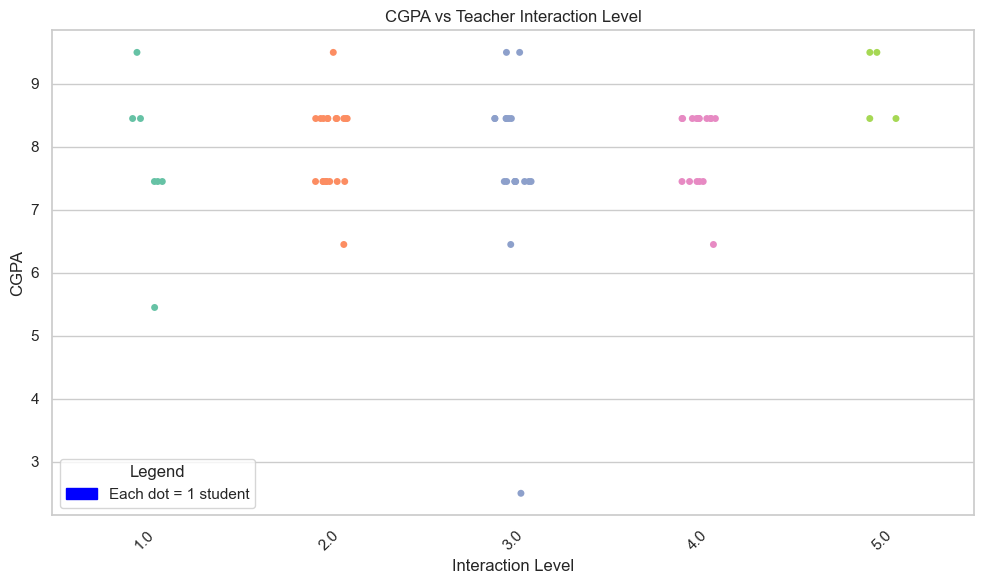

In [21]:
import matplotlib.patches as mpatches

sns.stripplot(data=new_df, x='teacher_interaction', y='Cgp', palette='Set2', jitter=True)

plt.title('CGPA vs Teacher Interaction Level')
plt.xlabel('Interaction Level')
plt.ylabel('CGPA')
plt.xticks(rotation=45)
blue_patch = mpatches.Patch(color='blue', label='Each dot = 1 student')
plt.legend(handles=[blue_patch], title='Legend')
plt.tight_layout()
plt.show()

### 4. Comparitative Bar - based on the setaing zones 

In [22]:
zone_cols = ['Zone_Back', 'Zone_Front', 'Zone_Middle', 'Zone_Sides']

def get_attentive_zone(row):
    for col in zone_cols:
        if row[col] == 1:
            return col.replace('Zone_', '')
    return 'Unknown'

new_df['Attentive_zone'] = new_df.apply(get_attentive_zone, axis=1)

ValueError: min() arg is an empty sequence

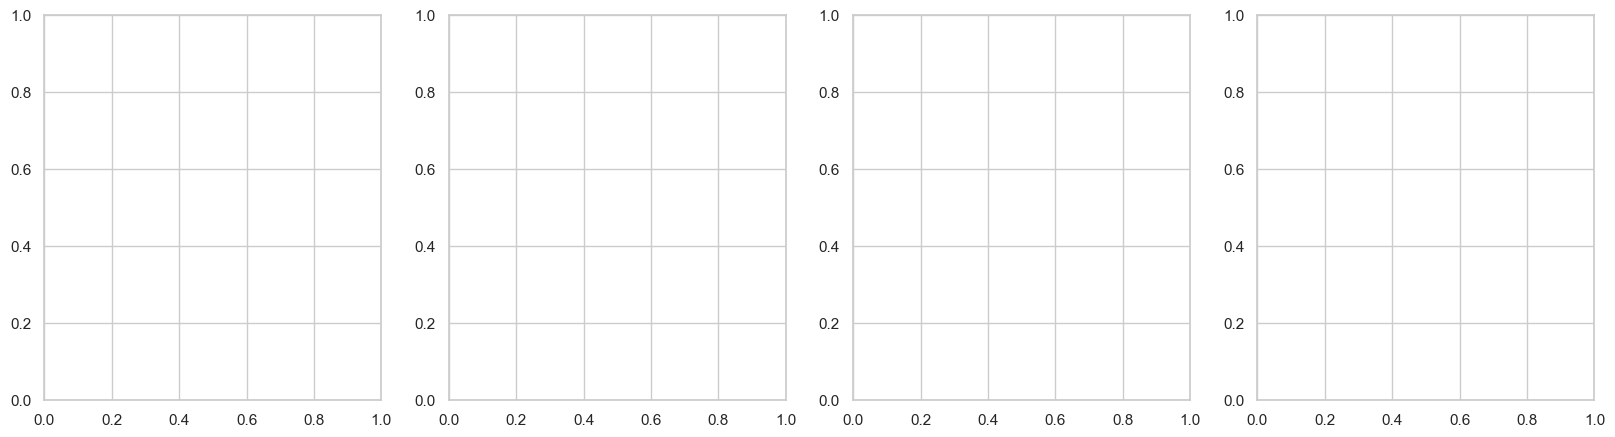

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure 'Cgp' is numeric
new_df['Cgp'] = pd.to_numeric(new_df['Cgp'], errors='coerce')
new_df = new_df.dropna(subset=['Cgp'])

# List of zone columns
zone_columns = ['Zone_Back', 'Zone_Front', 'Zone_Middle', 'Zone_Sides']

# Set up subplots
fig, axes = plt.subplots(1, len(zone_columns), figsize=(20, 5))

# Loop through each zone and plot
for i, col in enumerate(zone_columns):
    zone_data = new_df.groupby(col)['Cgp'].mean().reset_index()
    zone_data[col] = zone_data[col].map({0: 'Did Not Sit', 1: 'Sat'})
    
    ax = axes[i]
    sns.barplot(data=zone_data, x=col, y='Cgp', palette='pastel', ax=ax)
    ax.set_title(f'Average CGP - {col.replace("Zone_", "")}')
    ax.set_xlabel('')
    ax.set_ylabel('Average CGP')

plt.tight_layout()
plt.show()


## Model Training: Predicting Student Academic Performance Based on Seating Preferences

In [ ]:
print(new_df['Cgp'].unique())

In [ ]:
def classify_cgp(cgp):
    if cgp >= 8.0:
        return 'High'
    elif cgp >= 6.0:
        return 'Medium'
    else:
        return 'Low'
    

# Apply classification
new_df['Performance_Level'] = new_df['Cgp'].apply(classify_cgp)

# Merge Low and Medium into Low-Medium for binary classification
new_df['Performance_Level'] = new_df['Performance_Level'].replace({
    'Low': 'Low-Medium',
    'Medium': 'Low-Medium'
})

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix


df_model = new_df.drop(columns=[
    'Name',       # Personal identifiers
    'Cgp'         # Original numeric CGPA, now we use the label
])

# Drop rows with missing target
df_model = df_model.dropna(subset=['Performance_Level'])

# Drop remaining rows with missing values (optional)
df_model = df_model.dropna()

# Split into features and labels
X = df_model.drop(columns=['Performance_Level'])
y = df_model['Performance_Level']

# One-hot encode categorical features
X_encoded = pd.get_dummies(X)

#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

# Train Random Forest Model

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)



# Evaluate Model
y_pred = model.predict(X_test)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Plot Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap="Blues", fmt="d",
            xticklabels=['High', 'Low-Medium'], yticklabels=['High', 'Low-Medium'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



### Top 10 Features Influencing the Model’s Prediction

In [ ]:
feature_importance = pd.Series(model.feature_importances_, index=X_encoded.columns)
top_features = feature_importance.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_features.values, y=top_features.index)
plt.title("Top 10 Important Features")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()